# Recomendación de películas

Importando librerías principales

In [1]:
import pandas as pd
import numpy as np

Importando datasets de Kaggle

In [2]:
import os
import kagglehub

path_kaggle_data = kagglehub.dataset_download("parasharmanas/movie-recommendation-system")
movies_csv = os.path.join(path_kaggle_data, "movies.csv")
movies_df = pd.read_csv(movies_csv)

ratings_csv = os.path.join(path_kaggle_data, "ratings.csv")
ratings_df = pd.read_csv(ratings_csv)

Extrayendo un procentaje de cada calificación:

- Se extrajo el procentaje correspondiente de cada puntaje de rating que compone a todo el dataset.

In [3]:
df_ratings_samples = []
for rating in ratings_df["rating"].unique():
    grupo = ratings_df.loc[ratings_df["rating"]==rating]
    if len(grupo) >= 1000:
        prop = len(grupo)/len(ratings_df)
        df_ratings_samples.append(grupo.sample(frac=prop))
    else:
        print("Hay poco valores")

df_ratings_samples = pd.concat(df_ratings_samples).reset_index(drop=True)
print("Cantidad de datos por puntaje de rating")
print(df_ratings_samples["rating"].value_counts())

Cantidad de datos por puntaje de rating
rating
4.0    1763470
3.0     959193
5.0     521997
3.5     403812
4.5     193694
2.0     107698
2.5      63786
1.0      24138
1.5       6384
0.5       6180
Name: count, dtype: int64


In [4]:
import re
def clean_title(title):
    return re.sub("[^a-zA-Z0-9 ]", "", title)

- Convirtiendo en listas, los generos correspondientes de cada película.
- Limpiando cada título de película con la funcion ```clean_title```.

In [5]:
movies_df["genres"] = movies_df["genres"].apply(lambda x: x.split("|"))
movies_df["title"] = movies_df["title"].apply(clean_title)

Géneros únicos

In [6]:
generos_unicos = pd.Series([genero for lista_genero in movies_df["genres"] for genero in lista_genero]).unique()
generos_unicos

array(['Adventure', 'Animation', 'Children', 'Comedy', 'Fantasy',
       'Romance', 'Drama', 'Action', 'Crime', 'Thriller', 'Horror',
       'Mystery', 'Sci-Fi', 'IMAX', 'Documentary', 'War', 'Musical',
       'Western', 'Film-Noir', '(no genres listed)'], dtype=object)

Separando las películas que cuentan con géneros definidos, excluyendo a **'(no genres listed)'**.

In [7]:
sin_genero = movies_df[movies_df["genres"].apply(lambda x: '(no genres listed)' in x)]
con_genero = movies_df[~movies_df["genres"].apply(lambda x: '(no genres listed)' in x)]

## Descripcion del Dataframe

Uniendo el dataframe de puntajes (rating) con el dataframe que cuenta con géneros definidos

In [8]:
ratings_movies = pd.merge(df_ratings_samples, con_genero, on="movieId")
ratings_movies.head()

,userId,movieId,rating,timestamp,title,genres
0,142611,2959,5.0,1013593744,Fight Club 1999,"[Action, Crime, Drama, Thriller]"
1,74989,903,5.0,1450476638,Vertigo 1958,"[Drama, Mystery, Romance, Thriller]"
2,113007,1272,5.0,958172335,Patton 1970,"[Drama, War]"
3,53374,1042,5.0,942053942,That Thing You Do 1996,"[Comedy, Drama]"
4,158772,26133,5.0,1446413266,Charlie Brown Christmas A 1965,"[Animation, Children, Comedy]"


Las 10 películas que llevaron mas audicencia

In [9]:
audiencia_por_pelicula = ratings_movies.groupby("title")["rating"].count().reset_index(drop=False).sort_values("rating", ascending=False).head(10).reset_index(drop=True).rename(columns={"title":"pelicula","rating":"audiencia"})
print(audiencia_por_pelicula)

                                pelicula  audiencia
0                      Forrest Gump 1994      13970
1          Shawshank Redemption The 1994      13186
2                      Pulp Fiction 1994      13036
3          Silence of the Lambs The 1991      12923
4                        Matrix The 1999      11989
5  Star Wars Episode IV  A New Hope 1977      11484
6                     Jurassic Park 1993      11382
7                   Schindlers List 1993      10266
8                         Toy Story 1995      10206
9         Terminator 2 Judgment Day 1991      10184


Promedio de rating por película

In [10]:
promedio_rating = ratings_movies.groupby("title")["rating"].mean().reset_index(drop=False).sort_values("rating",ascending=False).reset_index(drop=True).rename(columns={"title":"pelicula","rating":"rating promedio"}).head(10)
print(promedio_rating)

                                            pelicula  rating promedio
0                                     Nude Area 2014              5.0
1                        100 Degrees Below Zero 2013              5.0
2                                               2015              5.0
3                                         Reich 2001              5.0
4                      Red Shoes The Bunhongsin 2005              5.0
5                                       Removal 2010              5.0
6                                 At Ellens Age 2011              5.0
7  Reel Bad Arabs How Hollywood Vilifies a People...              5.0
8                                 Reality Check 2002              5.0
9  Legend of the Black Scorpion aka The Banquet Y...              5.0


Cantidad de espectadores por género

In [11]:
rating_movies_expl = ratings_movies.explode("genres")
print(rating_movies_expl.groupby("genres")["userId"].nunique().sort_values(ascending=False).head(10).reset_index(drop=False).rename(columns={"genres":"genero", "userId":"audiencia"}))

      genero  audiencia
0      Drama     153955
1     Comedy     147271
2     Action     143601
3   Thriller     142465
4  Adventure     139536
5      Crime     130360
6    Romance     129582
7     Sci-Fi     124348
8    Fantasy     110174
9    Mystery      98490


Las 3 películas con mejor puntaje de rating agrupado por género

In [12]:
rating_movies_expl.groupby(["genres","title"])["rating"].mean().reset_index(drop=False).sort_values(["genres","rating"], ascending=[True,False]).groupby("genres").head(3).reset_index(drop=True).rename(columns={"genres":"genero","title":"pelicula","rating":"promedio rating"})

,genero,pelicula,promedio rating
0,Action,100 Degrees Below Zero 2013,5.000000
1,Action,2 Jennifer 2016,5.000000
2,Action,6 Ways to Die 2015,5.000000
3,Adventure,2015,5.000000
4,Adventure,About the Little Red Riding Hood 1977,5.000000
5,Adventure,Adventures of Mowgli Akelas Last Hunt 1969,5.000000
6,Animation,2015,5.000000
7,Animation,Adventures of Mowgli Akelas Last Hunt 1969,5.000000
8,Animation,Adventures of Mowgli Return to Mankind 1971,5.000000
9,Children,About the Little Red Riding Hood 1977,5.000000


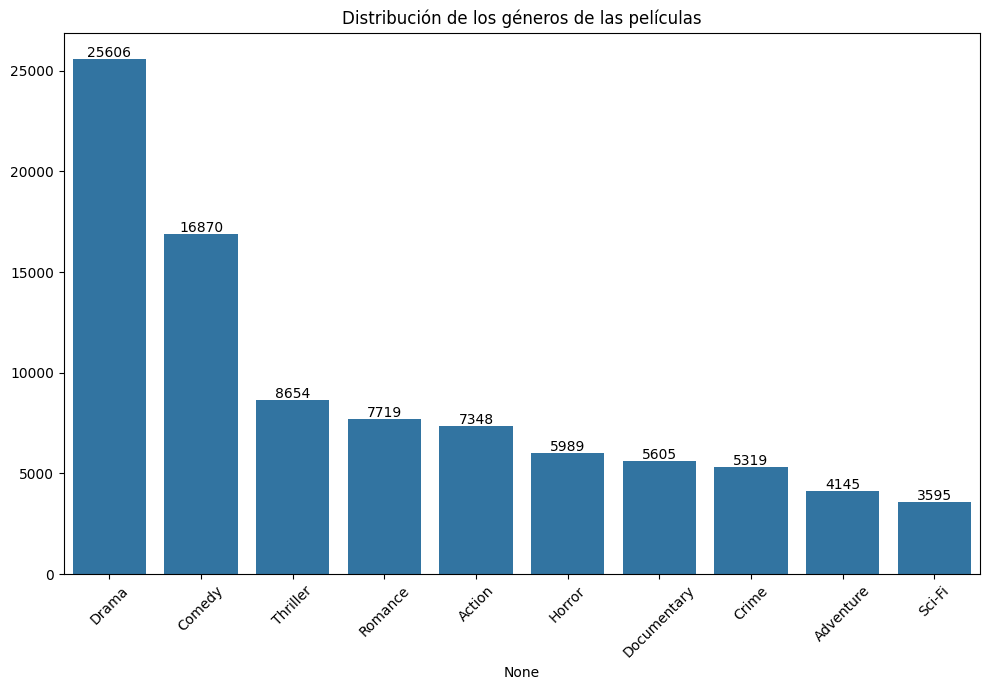

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

generos_peliculas = [genero for lista_genero in con_genero["genres"] for genero in lista_genero]
generos_peliculas = pd.Series(generos_peliculas).value_counts().head(10)

plt.figure(figsize=(10, 7))
sns.barplot(x=generos_peliculas.index, y=generos_peliculas.values)

plt.title("Distribución de los géneros de las películas")
for i, valor in enumerate(generos_peliculas.values):
    plt.text(i, valor + 100, str(valor), ha='center')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Diseño del modelo de TF - IDF con stopwords y la similitud de coseno

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.corpus import stopwords
from nltk.tokenize import wordpunct_tokenize
import nltk
# nltk.download('punkt')
# nltk.download('stopwords')

titulos = con_genero["title"]
#tokenizar los titulos (aplicado individualmente a cada título)
tokens_titulos = titulos.apply(wordpunct_tokenize)
# obteniendo la lista de stopwords en ingles
stop_words = set(stopwords.words('english'))
# filtrando los stopwords de cada título tokenizado
filtered_titles = tokens_titulos.apply(
    lambda token_titulo: " ".join([word for word in token_titulo if word.lower() not in stop_words])
)
filtered_titles

0                   Toy Story 1995
1                     Jumanji 1995
2            Grumpier Old Men 1995
3              Waiting Exhale 1995
4        Father Bride Part II 1995
                   ...            
62417     Santosh Subramaniam 2008
62418                         2018
62419             Window Soul 2001
62420               Bad Poems 2018
62422     Women Devils Island 1962
Name: title, Length: 57361, dtype: object

Vectorización de los títulos filtrados

In [46]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2))
vectorizer_titles = vectorizer.fit_transform(filtered_titles)

def busqueda_titulo(titulo):
    titulo = clean_title(titulo)
    query_title = vectorizer.transform([titulo])
    similitud = cosine_similarity(vectorizer_titles, query_title).flatten()
    indices = np.argpartition(similitud, -5)[-5:]
    resultados = con_genero.iloc[indices][::-1]
    return resultados


## Busqueda de películas similares por el título

Búsqueda de películas similares al título de la película **Interstellar**

In [34]:
resultados_peliculas = busqueda_titulo("Interstellar")
print(resultados_peliculas["title"].reset_index(drop=True))

0                   Interstellar 2014
1    The Science of Interstellar 2014
2                   Visitors The 1972
3           Excuse Me for Living 2012
4               Sea of Grass The 1947
Name: title, dtype: object


Búsqueda de películas similares al título de la película **Fast and Furious**

In [ ]:
resultados_peliculas1 = busqueda_titulo("Fast and Furious")
print(resultados_peliculas1["title"].reset_index(drop=True))

0     Fast  Furious 6 Fast and the Furious 6 The 2013
1       Fast  Furious Fast and the Furious 4 The 2009
2    2 Fast 2 Furious Fast and the Furious 2 The 2003
3                       Fast and the Furious The 2001
4                       Fast and the Furious The 1955
Name: title, dtype: object
